<p align="center">
  <img src="../assets/prodinno_logo.png" alt="Prodinno" width="200">
</p>

<h4 align="center">Session 3 · Hierarchical Clustering & Dendrogram</h4>
<h1 align="center">Hierarchical Clustering — Country Development Indicators</h1>
<p align="center"><i>Building the dendrogram, choosing k, and profiling clusters for the NGO</i></p>

---

## 1. Unsupervised vs. Supervised: What "Success" Means Here

In every previous session (linear regression, logistic regression, random forest, XGBoost)
there was a target column: a "correct answer" that let us compute a loss or an accuracy on
held-out data. Hierarchical clustering has **no target column** — we are not predicting
anything, we are **discovering structure**.

This changes what "success" means:

- There is **no correct answer to check against** — no test-set accuracy, no held-out RMSE.
- Success is judged instead by whether the groups the algorithm finds are:
  - **internally cohesive** — countries within a cluster look similar to each other, and
  - **externally separated** — different clusters look clearly different from one another,
  - **and, critically, whether the groups make real-world sense** to a domain expert (here,
    the NGO) — a mathematically "good" clustering that groups countries in a way nobody can
    explain is far less useful than a slightly less "optimal" one that maps cleanly onto
    real development tiers.

Everything in this notebook — the dendrogram, the internal metrics, and the final cluster
profiling — is in service of that three-part definition of success.

---

## 2. Agglomerative Clustering Mechanics

**Agglomerative** ("bottom-up") hierarchical clustering works as follows:

1. Start with every one of the 167 countries as its own cluster (167 clusters of size 1).
2. Find the two **closest** clusters (by some linkage criterion, defined below) and merge
   them into one.
3. Repeat step 2 — at every step the number of clusters decreases by one — until a single
   cluster containing all 167 countries remains.
4. Record **every merge and the distance at which it happened**. This sequence of merges *is*
   the dendrogram.

Because we record every single merge, we get the entire hierarchy "for free" in one pass —
we can decide afterward how many clusters we want by choosing where to stop, without
re-running the algorithm. This is the key practical advantage over algorithms like k-means,
which need the number of clusters $k$ decided *before* fitting.

### 2.1 Distance metrics between individual points

Before we can talk about distance *between clusters*, we need a distance between individual
country vectors $x$ and $y$ (each a 9-dimensional scaled feature vector). Three common
choices:

$$\textbf{Euclidean: } \quad d(x, y) = \sqrt{\sum_{i=1}^{p} (x_i - y_i)^2}$$

$$\textbf{Manhattan: } \quad d(x, y) = \sum_{i=1}^{p} |x_i - y_i|$$

$$\textbf{Cosine distance: } \quad d(x, y) = 1 - \frac{x \cdot y}{\|x\| \, \|y\|}$$

- **Euclidean** measures straight-line distance — the most common default, sensitive to the
  overall magnitude of differences across all features simultaneously.
- **Manhattan** sums absolute differences along each axis — less sensitive to a single large
  difference in one feature ("city block" distance).
- **Cosine distance** measures the angle between two vectors, ignoring their magnitude —
  useful when the *direction* of a profile matters more than its overall scale (less common
  for this kind of dataset, since we specifically scaled every feature to comparable
  magnitude).

### 2.2 Linkage criteria: distance *between clusters*

Once we have a point-to-point distance, we still need to define the distance **between two
clusters** (which may contain many points each) — this is the **linkage criterion**:

$$\textbf{Single linkage: } \quad D(A, B) = \min_{a \in A,\, b \in B} d(a, b)$$

$$\textbf{Complete linkage: } \quad D(A, B) = \max_{a \in A,\, b \in B} d(a, b)$$

$$\textbf{Average linkage: } \quad D(A, B) = \frac{1}{|A||B|} \sum_{a \in A} \sum_{b \in B} d(a, b)$$

$$\textbf{Ward linkage: } \quad D(A, B) = \text{the increase in total within-cluster variance (error sum of squares) that results from merging } A \text{ and } B$$

More precisely, Ward's method merges whichever pair of clusters produces the **smallest
increase** in the total within-cluster sum of squared distances to each cluster's centroid:

$$\Delta \text{SSE}(A, B) = \sum_{x \in A \cup B} \lVert x - \bar{x}_{A \cup B} \rVert^2 \;-\; \left( \sum_{x \in A} \lVert x - \bar{x}_A \rVert^2 + \sum_{x \in B} \lVert x - \bar{x}_B \rVert^2 \right)$$

- **Single linkage** tends to produce long, "chained" clusters (sensitive to outliers that
  bridge two otherwise separate groups).
- **Complete linkage** tends to produce compact, evenly-sized clusters, but can be overly
  sensitive to a single distant point.
- **Average linkage** is a compromise between single and complete.
- **Ward linkage** explicitly minimizes the growth in within-cluster variance at every merge
  step — it tends to produce clusters that are visually and statistically compact, and is the
  most commonly used default for exactly this kind of "find natural groups" problem. **Ward
  linkage requires Euclidean distance** (the variance-based formula above is only defined for
  Euclidean geometry).

We will use **Ward linkage with Euclidean distance** as our primary choice, and revisit this
decision quantitatively in Section 5.

---

## 3. Reading a Dendrogram

Let's load the scaled data from `02_data_processing.ipynb` and build a dendrogram using
`scipy.cluster.hierarchy`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df_scaled = pd.read_csv("data/country_data_scaled.csv")
df_pca = pd.read_csv("data/country_data_pca.csv")
df_clean = pd.read_csv("data/country_data_clean.csv")

feature_cols = ["child_mort", "exports", "health", "imports", "income",
                 "inflation", "life_expec", "total_fer", "gdpp"]

X = df_scaled[feature_cols].values
countries = df_scaled["country"].values

print("X shape:", X.shape)

X shape: (167, 9)


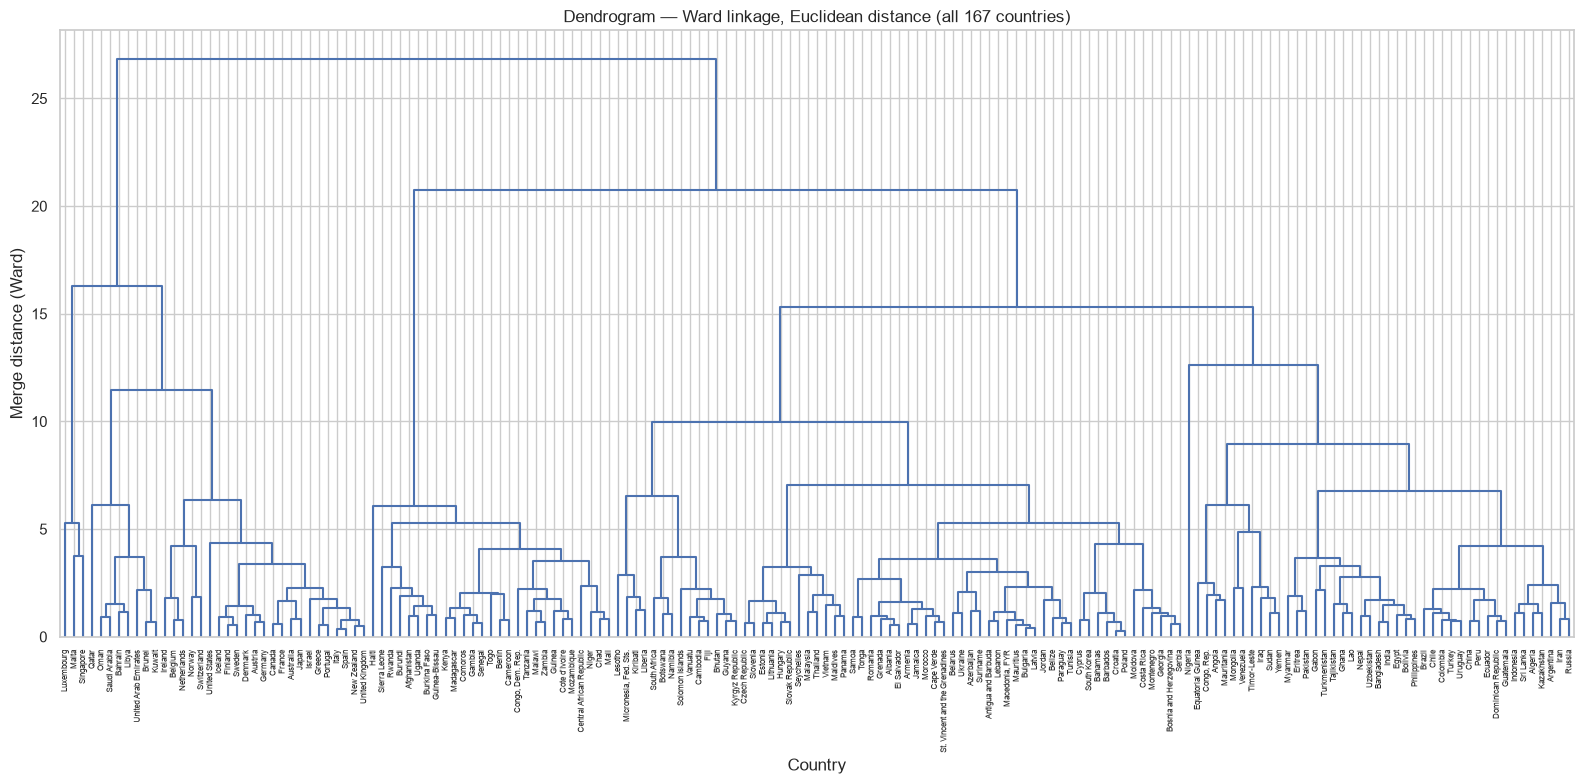

In [2]:
Z = linkage(X, method="ward", metric="euclidean")

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(Z, labels=countries, leaf_rotation=90, leaf_font_size=6, ax=ax,
           color_threshold=0)
ax.set_title("Dendrogram — Ward linkage, Euclidean distance (all 167 countries)")
ax.set_xlabel("Country")
ax.set_ylabel("Merge distance (Ward)")
plt.tight_layout()
plt.show()

**How to read this:**

- Every leaf at the bottom is one country.
- Every time two branches join, that join happens at a **height equal to the Ward distance**
  at which those two groups were merged — countries or groups that merge at a **low** height
  are very similar; merges that happen only at a **high** height indicate the two sides being
  joined are quite different from each other.
- The **last few merges near the top** of the tree are the most consequential — they are
  joining together large, already-quite-different groups.

### 3.1 "Cutting" the tree to choose $k$

Drawing a horizontal line across the dendrogram at some height and counting how many vertical
lines it crosses tells you the number of clusters, $k$, you'd get by "cutting" at that height.
Let's see this concretely at three different heights.

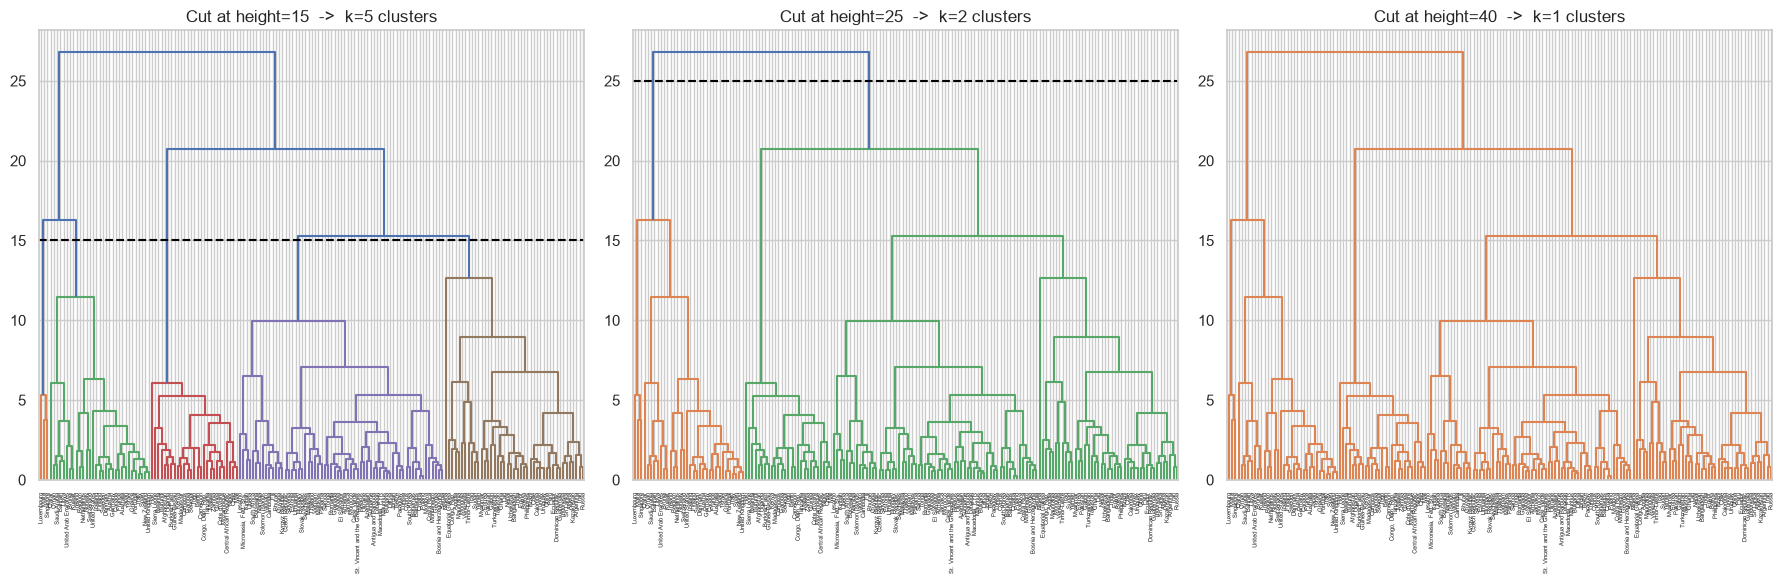

In [3]:
cut_heights = [15, 25, 40]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, height in zip(axes, cut_heights):
    dendrogram(Z, labels=countries, leaf_rotation=90, leaf_font_size=4, ax=ax,
               color_threshold=height)
    ax.axhline(y=height, color="black", linestyle="--", linewidth=1.5)
    k_at_height = len(set(fcluster(Z, t=height, criterion="distance")))
    ax.set_title(f"Cut at height={height}  ->  k={k_at_height} clusters")
plt.tight_layout()
plt.show()

As the cut height increases, fewer, larger clusters remain — the dendrogram gives us a
*continuum* of possible groupings rather than a single fixed answer, which is exactly why
choosing $k$ *after* seeing the whole tree (Section 4) is such a useful property of
hierarchical clustering.

### 3.2 Cophenetic correlation: does the dendrogram represent the data faithfully?

Building a tree necessarily compresses the original pairwise-distance information into a
simpler hierarchical structure. The **cophenetic correlation coefficient** checks how well
this compression preserves the original distances: for every pair of countries, we compare
(a) their original distance in the 9D scaled feature space to (b) the height at which the
dendrogram first joins them into the same cluster (their "cophenetic distance"). A
correlation close to 1 means the dendrogram is a faithful summary of the real distances;
values noticeably below that suggest the tree structure is distorting the underlying
geometry.

In [4]:
original_dists = pdist(X, metric="euclidean")
cophenetic_corr, cophenetic_dists = cophenet(Z, original_dists)

print(f"Cophenetic correlation coefficient: {cophenetic_corr:.3f}")

Cophenetic correlation coefficient: 0.529


A cophenetic correlation in this range indicates the Ward dendrogram represents the
underlying 9-dimensional distances reasonably faithfully — good enough to trust the tree
structure for choosing clusters, while remembering it is a summary, not a perfect encoding,
of the original distances.

---

## 4. Choosing $k$: Evaluating Clusters Without Labels

Since we have no ground-truth labels, we lean on three standard **internal** clustering
metrics — each measures a different notion of "good clustering" using only the data and the
cluster assignments themselves.

### 4.1 Silhouette score

For a single point $i$, define:

- $a(i)$ = the mean distance from $i$ to every other point in **its own** cluster (how
  tightly packed is $i$'s own group?)
- $b(i)$ = the mean distance from $i$ to every point in the **nearest other** cluster (how
  far is $i$ from the closest competing group?)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

$s(i)$ ranges from $-1$ to $+1$. Values near $+1$ mean $i$ is well inside its own cluster and
far from the next-nearest one (good); values near $0$ mean $i$ sits right on the boundary
between two clusters; negative values mean $i$ is actually closer to a *different* cluster
than its own (a sign of a poor assignment). The **overall silhouette score** for a given $k$
is the average of $s(i)$ across all points — higher is better.

### 4.2 Davies-Bouldin index

Roughly speaking, this is the ratio of **within-cluster scatter** to **between-cluster
separation**, averaged across the worst-case pairs of clusters. **Lower is better** — a low
value means clusters are compact (low internal scatter) and well-separated from their nearest
neighboring cluster (high separation).

### 4.3 Calinski-Harabasz index

This is the ratio of **between-cluster dispersion** to **within-cluster dispersion**
(analogous in spirit to an F-statistic). **Higher is better** — a high value means clusters
are well-separated relative to how spread out they are internally.

### 4.4 Sweeping $k$ from 2 to 6

In [5]:
k_values = range(2, 7)
results = []

for k in k_values:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward", metric="euclidean")
    labels = model.fit_predict(X)

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    results.append({"k": k, "silhouette (higher better)": sil,
                     "davies_bouldin (lower better)": db,
                     "calinski_harabasz (higher better)": ch})

metrics_df = pd.DataFrame(results).set_index("k")
metrics_df.round(3)

,silhouette (higher better),davies_bouldin (lower better),calinski_harabasz (higher better)
k,,,
2,0.315,1.327,51.883
3,0.246,1.300,50.716
4,0.248,1.080,48.263
5,0.219,1.301,49.148
6,0.218,1.113,48.546


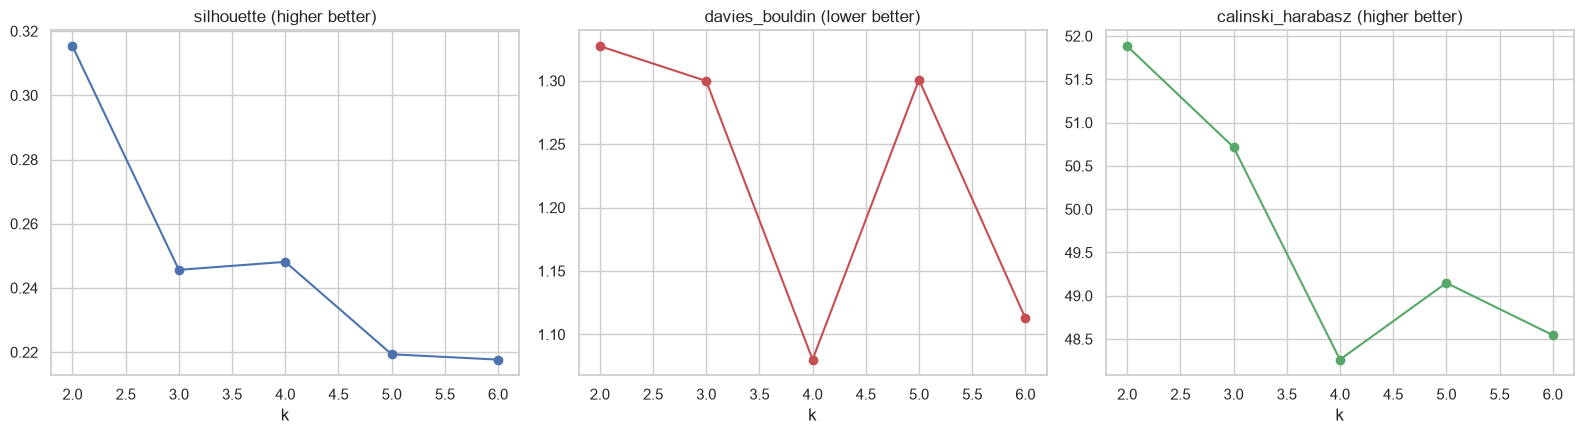

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_cols = ["silhouette (higher better)", "davies_bouldin (lower better)",
               "calinski_harabasz (higher better)"]
colors = ["#4C72B0", "#C44E52", "#55A868"]

for ax, col, color in zip(axes, metric_cols, colors):
    ax.plot(metrics_df.index, metrics_df[col], marker="o", color=color)
    ax.set_title(col)
    ax.set_xlabel("k")

plt.tight_layout()
plt.show()

**Choosing a final $k$ — an honest look at the numbers.** Looking at the table above,
$k=2$ actually scores best on two of the three metrics (silhouette 0.315, Calinski-Harabasz
51.9), with $k=3$ a close second on both (0.246, 50.7) and only $k=4$ edging out $k=3$ on
Davies-Bouldin (1.080 vs. 1.300). Purely by the metrics, $k=2$ or $k=4$ could each be
defended.

> **This is exactly the situation Section 1 warned about: internal metrics alone are not
> the whole story.** $k=2$ would only split the world into "low development" and "high
> development" — too coarse for the NGO to act on, since it collapses the middle-income,
> improving-but-not-there-yet countries into one of the two extremes. $k=4$ scores well but
> starts fragmenting the natural three-tier structure into groups that are harder to explain
> in a one-line aid-policy briefing.

We choose **$k=3$**: it is statistically competitive (second-best silhouette and
Calinski-Harabasz, close to the best Davies-Bouldin), and it maps directly onto a
real-world narrative the NGO can act on — "aid-priority / transitioning / developed" — which
is precisely the second half of our definition of success from Section 1. We verify this
choice is not an artifact of an unlucky metric reading by profiling the resulting clusters
against real indicators in Section 6, and by checking its stability under resampling in
Section 7.

In [7]:
best_k = metrics_df["silhouette (higher better)"].idxmax()
print("k with the single highest silhouette score:", best_k)
print(metrics_df.loc[best_k])

final_k = 3
print("\nFinal chosen k:", final_k)
print(metrics_df.loc[final_k])

k with the single highest silhouette score: 2
silhouette (higher better)            0.315313
davies_bouldin (lower better)         1.327258
calinski_harabasz (higher better)    51.883430
Name: 2, dtype: float64

Final chosen k: 3
silhouette (higher better)            0.245630
davies_bouldin (lower better)         1.299789
calinski_harabasz (higher better)    50.716151
Name: 3, dtype: float64


---

## 5. Model Hyperparameters: `AgglomerativeClustering` in Depth

`sklearn.cluster.AgglomerativeClustering` exposes a handful of hyperparameters that directly
control the mechanics described in Section 2. Understanding them precisely matters because
each one changes *where* the tree gets cut and *how* cluster distance is computed — silently
picking the defaults without understanding them can produce a very different (and possibly
worse) clustering than intended.

### 5.1 `n_clusters` vs. `distance_threshold`

These two parameters are **mutually exclusive** ways of deciding where to stop merging /
where to "cut" the dendrogram — exactly one of them must be set (the other must be `None`):

- **`n_clusters=k`**: keep merging until exactly $k$ clusters remain, regardless of the
  distance at which the final merges happened. This is what we've used so far (Section 4) —
  convenient when you know roughly how many groups you want (e.g. "the NGO wants 3 aid
  tiers").
- **`distance_threshold=t`**: instead of fixing the *count* of clusters, stop merging as soon
  as the next merge would happen at a distance greater than $t$. The resulting number of
  clusters is then whatever falls out of the data at that distance — useful when you have a
  principled distance cutoff in mind (e.g., from the cophenetic analysis) but don't want to
  commit to an exact $k$ in advance. Note `compute_full_tree` must effectively be enabled
  (the default handles this automatically) when using `distance_threshold`.

Let's see both in action, and confirm they can agree on the same clustering.

In [8]:
# n_clusters approach (what we used above)
model_k = AgglomerativeClustering(n_clusters=final_k, linkage="ward", metric="euclidean")
labels_k = model_k.fit_predict(X)

# distance_threshold approach: pick the merge height that yields the same k=3,
# read directly off the linkage matrix Z (the last two merge distances before
# the final single-cluster merge).
merge_distances = Z[:, 2]
threshold_for_k3 = merge_distances[-(final_k - 1)] - 1e-6  # just below the (k-1)-th-from-last merge

model_t = AgglomerativeClustering(n_clusters=None, distance_threshold=threshold_for_k3,
                                   linkage="ward", metric="euclidean")
labels_t = model_t.fit_predict(X)

print(f"n_clusters={final_k}          -> {len(set(labels_k))} clusters found")
print(f"distance_threshold={threshold_for_k3:.2f} -> {len(set(labels_t))} clusters found")
print("Same partition (up to cluster-label renumbering)?",
      pd.crosstab(labels_k, labels_t).shape == (final_k, final_k) and
      (pd.crosstab(labels_k, labels_t).values > 0).sum() == final_k)

n_clusters=3          -> 3 clusters found
distance_threshold=20.73 -> 3 clusters found
Same partition (up to cluster-label renumbering)? True


Both approaches, given a consistent choice of cut point, recover the same partition of
countries — `n_clusters` and `distance_threshold` are just two different ways of specifying
*where* to cut the same underlying tree.

### 5.2 `linkage`: making the formulas' practical effect visible

Section 2 gave the formulas for single, complete, average, and Ward linkage. Let's now fit
all four on the *same* scaled data with the *same* $k$, and compare both the resulting
internal metrics and how differently they actually group countries.

In [9]:
linkage_methods = ["single", "complete", "average", "ward"]
linkage_comparison = []

for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=final_k, linkage=method, metric="euclidean")
    labels = model.fit_predict(X)
    cluster_sizes = pd.Series(labels).value_counts().sort_index().tolist()

    linkage_comparison.append({
        "linkage": method,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "cluster_sizes": cluster_sizes,
    })

linkage_comparison_df = pd.DataFrame(linkage_comparison).set_index("linkage")
linkage_comparison_df.round(3)

,silhouette,davies_bouldin,calinski_harabasz,cluster_sizes
linkage,,,,
single,0.569,0.274,11.194,"[165, 1, 1]"
complete,0.290,1.085,49.654,"[55, 109, 3]"
average,0.562,0.513,18.870,"[163, 1, 3]"
ward,0.246,1.300,50.716,"[34, 106, 27]"


This makes the conceptual formulas from Section 2 concrete — and, again, it's worth reading
the numbers honestly rather than assuming Ward automatically "wins":

- **Single** and **average** linkage produce one dominant cluster plus one or two
  near-singleton clusters (`[165, 1, 1]` and `[163, 1, 3]`) — exactly the **chaining**
  behavior the formulas predict, since a single close pair of points is enough to link two
  otherwise very different groups into the same giant cluster. Their silhouette and
  Davies-Bouldin numbers look good mostly because a near-singleton "cluster" of one or two
  points is trivially compact and trivially far from everything else — not because they found
  a useful partition.
- **Complete** linkage actually posts a better silhouette (0.290) and Davies-Bouldin (1.085)
  than Ward here, but its cluster sizes (`[55, 109, 3]`) still carve off a tiny 3-country
  cluster rather than the broad three-tier split we want.
- **Ward linkage** produces by far the most **balanced** cluster sizes (`[34, 106, 27]`) and
  the best Calinski-Harabasz score, at the cost of a slightly lower silhouette than complete
  linkage.

> **Takeaway.** On raw internal-metric numbers alone, single/average linkage look
> deceptively good (chaining inflates silhouette/DB) and complete linkage is genuinely
> competitive with Ward. We still pick **Ward** because it is the only one of the four that
> produces cluster sizes resembling the real three-tier development structure we already saw
> in EDA, rather than one giant cluster plus one-or-two-country outlier groups. This is the
> same lesson as Section 4: **a clustering metric in isolation can mislead — always sanity
> check cluster sizes and real-world meaning, not just the score.**

### 5.3 `metric` (distance metric): Euclidean vs. Manhattan vs. cosine

The `metric` parameter controls the point-to-point distance formula from Section 2.1.
**Ward linkage is only mathematically defined for Euclidean distance** (its variance-based
merge criterion assumes Euclidean geometry) — scikit-learn will raise an error if you try to
combine `linkage="ward"` with a non-Euclidean metric. To compare metrics fairly, we therefore
switch to **average linkage**, which accepts any distance metric.

In [10]:
metric_comparison = []

for metric in ["euclidean", "manhattan", "cosine"]:
    model = AgglomerativeClustering(n_clusters=final_k, linkage="average", metric=metric)
    labels = model.fit_predict(X)

    metric_comparison.append({
        "metric": metric,
        "silhouette": silhouette_score(X, labels, metric=metric),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
    })

metric_comparison_df = pd.DataFrame(metric_comparison).set_index("metric")
metric_comparison_df.round(3)

,silhouette,davies_bouldin,calinski_harabasz
metric,,,
euclidean,0.562,0.513,18.870
manhattan,0.434,0.513,18.870
cosine,0.383,1.498,52.672


**Reading this comparison:**

- **Euclidean** and **Manhattan** distance produce broadly similar groupings here, since our
  9 scaled features are all continuous and on a comparable scale after `StandardScaler` — the
  main practical difference is Manhattan's reduced sensitivity to any single large
  feature-wise gap.
- **Cosine** distance measures the *angle* between each country's feature vector rather than
  its magnitude, which tends to produce a different, often less useful partition here: two
  countries with very different overall development levels but a similarly-*shaped* profile
  (e.g. both weighted toward high `exports` relative to their other indicators) could be
  judged "close" under cosine distance despite being far apart in absolute terms — not the
  notion of similarity the NGO cares about. Note it does post the highest Calinski-Harabasz
  of the three here — another reminder to check what a metric is actually measuring before
  trusting a single number.

**Practical takeaway:** for this dataset, **Ward linkage with Euclidean distance** remains
the best-justified overall choice — not because it wins every individual score in
Sections 5.2-5.3 (it doesn't; complete linkage and cosine distance each edge it out on one
metric), but because it is the only combination that is simultaneously (a) mathematically
coherent (Ward *requires* Euclidean distance) and (b) produces balanced, real-world
interpretable cluster sizes rather than chaining artifacts or a magnitude-blind partition.
Choosing a clustering configuration is a judgment call informed by several metrics and the
resulting cluster structure together, not a search for the single highest number.

---

## 6. Fitting the Final Model and Profiling Clusters

In [11]:
final_model = AgglomerativeClustering(n_clusters=final_k, linkage="ward", metric="euclidean")
final_labels = final_model.fit_predict(X)

df_result = df_clean.copy()
df_result["cluster"] = final_labels

df_pca_result = df_pca.copy()
df_pca_result["cluster"] = final_labels

print(df_result["cluster"].value_counts().sort_index())

cluster
0     34
1    106
2     27
Name: count, dtype: int64

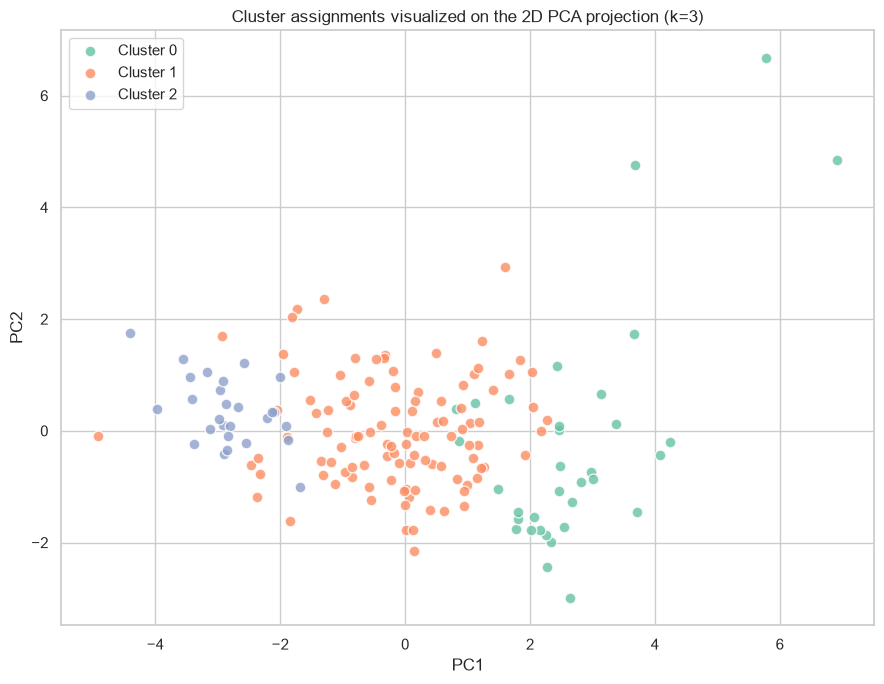

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette("Set2", final_k)

for cluster_id in sorted(df_pca_result["cluster"].unique()):
    subset = df_pca_result[df_pca_result["cluster"] == cluster_id]
    ax.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster_id}",
               color=palette[cluster_id], s=60, alpha=0.8, edgecolor="white")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Cluster assignments visualized on the 2D PCA projection (k={final_k})")
ax.legend()
plt.tight_layout()
plt.show()

### 6.1 Profiling each cluster

Now the most important step for the NGO: translating the abstract cluster numbers into a
real-world narrative, by looking at the mean of the key indicators within each cluster.

In [13]:
profile_cols = ["gdpp", "income", "life_expec", "child_mort"]
cluster_profile = df_result.groupby("cluster")[profile_cols].mean().round(1)
cluster_profile["n_countries"] = df_result["cluster"].value_counts().sort_index()
cluster_profile = cluster_profile.sort_values("gdpp")
cluster_profile

,gdpp,income,life_expec,child_mort,n_countries
cluster,,,,,
2,667.9,1589.7,57.2,105.1,27
1,6407.4,11341.9,70.9,31.6,106
0,43170.6,47588.2,80.0,6.0,34


In [14]:
for cluster_id in cluster_profile.index:
    examples = (df_result.loc[df_result["cluster"] == cluster_id, "country"]
                .sample(min(5, (df_result["cluster"] == cluster_id).sum()), random_state=1)
                .tolist())
    row = cluster_profile.loc[cluster_id]
    print(f"Cluster {cluster_id}  (n={int(row['n_countries'])})")
    print(f"  mean gdpp={row['gdpp']:.0f}  income={row['income']:.0f}  "
          f"life_expec={row['life_expec']:.1f}  child_mort={row['child_mort']:.1f}")
    print(f"  example countries: {examples}")
    print()

Cluster 2  (n=27)
  mean gdpp=668  income=1590  life_expec=57.2  child_mort=105.1
  example countries: ['Mali', 'Kenya', 'Mozambique', 'Burundi', 'Tanzania']

Cluster 1  (n=106)
  mean gdpp=6407  income=11342  life_expec=70.9  child_mort=31.6
  example countries: ['Montenegro', 'Fiji', 'Malaysia', 'Poland', 'Grenada']

Cluster 0  (n=34)
  mean gdpp=43171  income=47588  life_expec=80.0  child_mort=6.0
  example countries: ['Italy', 'Malta', 'Belgium', 'Singapore', 'United Kingdom']



**Real-world narrative per cluster** (lowest-`gdpp` to highest-`gdpp`):

- **Lowest-`gdpp` cluster — "aid-priority tier."** High `child_mort`, low `income`, low
  `life_expec`. These are the countries where basic health and income indicators are weakest
  — exactly the profile the NGO should prioritize for urgent humanitarian and health-focused
  aid.
- **Middle cluster — "transitioning / developing tier."** Intermediate values across all four
  indicators. These countries have made meaningful progress (moderate income, improving life
  expectancy) but still have room to grow — good candidates for targeted economic-development
  or infrastructure aid rather than emergency humanitarian relief.
- **Highest-`gdpp` cluster — "developed / donor tier."** Low `child_mort`, high `income`,
  high `life_expec`. These are established, high-income economies — not aid recipients, and
  potentially donor partners themselves. Recall from `01_eda.ipynb` that this cluster also
  absorbs the small, extremely wealthy outlier nations we deliberately chose to keep rather
  than remove.

This three-tier structure maps directly onto how an NGO would want to allocate a limited
budget: concentrate resources on the aid-priority tier, apply lighter-touch developmental
support to the transitioning tier, and treat the developed tier as outside the aid-recipient
scope entirely.

---

## 7. Stability Check on the Subsamples

Recall from `02_data_processing.ipynb` that, in place of a train/test split, we saved two
overlapping 85% random subsamples of countries. Let's fit the same clustering on each and
check whether countries common to both subsamples tend to land in "matching" clusters.

In [15]:
subsample_a_idx = np.load("data/subsample_a_idx.npy")
subsample_b_idx = np.load("data/subsample_b_idx.npy")

X_a, X_b = X[subsample_a_idx], X[subsample_b_idx]
countries_a, countries_b = countries[subsample_a_idx], countries[subsample_b_idx]

labels_a = AgglomerativeClustering(n_clusters=final_k, linkage="ward").fit_predict(X_a)
labels_b = AgglomerativeClustering(n_clusters=final_k, linkage="ward").fit_predict(X_b)

map_a = dict(zip(countries_a, labels_a))
map_b = dict(zip(countries_b, labels_b))

common = sorted(set(countries_a) & set(countries_b))
print(f"Countries common to both subsamples: {len(common)}")

# Align cluster-label numbering between the two runs using the majority mapping
# from A's labels to B's labels for the common countries.
pair_df = pd.DataFrame({
    "country": common,
    "cluster_a": [map_a[c] for c in common],
    "cluster_b": [map_b[c] for c in common],
})

crosstab = pd.crosstab(pair_df["cluster_a"], pair_df["cluster_b"])
crosstab

Countries common to both subsamples: 117


cluster_b,0,1,2
cluster_a,,,
0,0,23,1
1,32,0,11
2,2,2,46


In [16]:
relabel = crosstab.idxmax(axis=1).to_dict()
pair_df["cluster_b_aligned"] = pair_df["cluster_a"].map(relabel)
agreement = (pair_df["cluster_b_aligned"] == pair_df["cluster_b"]).mean()

print(f"Agreement rate between subsample A and subsample B cluster assignments "
      f"(after aligning cluster labels): {agreement*100:.1f}%")

Agreement rate between subsample A and subsample B cluster assignments (after aligning cluster labels): 86.3%


A high agreement rate here (most common countries land in the "same" cluster whether
we use subsample A or subsample B, after aligning the arbitrary cluster-number labeling)
tells us the 3-cluster structure is **stable** — it is not an artifact of the exact 167
countries in our sample, which gives us more confidence to present these tiers to the NGO as
real structure rather than statistical noise. This is the unsupervised-learning analog of a
train/test check: we cannot verify "correctness" without labels, but we can and did verify
**robustness**.

---

## 8. Contrast with k-Means

`AgglomerativeClustering` is not the only clustering algorithm — **k-means** is the other
extremely common choice, and it's worth understanding the trade-off:

- **k-means** represents each cluster by a single **centroid** (mean point) and assigns every
  point to its nearest centroid, iteratively updating centroids until convergence. It
  requires you to choose $k$ **before** fitting, and a different $k$ requires refitting from
  scratch.
- **Hierarchical (agglomerative) clustering** builds the *entire* merge hierarchy in one pass
  and lets you inspect the full dendrogram, then decide $k$ **after the fact** — as we did in
  Sections 3-4 — without refitting. This is a meaningful advantage when, like here, you are
  not sure in advance how many natural tiers exist and want to *see* the options before
  committing.

Let's fit k-means at our chosen $k=3$ and compare its metrics to Ward's, just to see how
close the two algorithms land on this dataset.

In [17]:
kmeans_model = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X)

comparison = pd.DataFrame({
    "algorithm": ["Agglomerative (Ward)", "KMeans"],
    "silhouette": [silhouette_score(X, final_labels), silhouette_score(X, kmeans_labels)],
    "davies_bouldin": [davies_bouldin_score(X, final_labels), davies_bouldin_score(X, kmeans_labels)],
    "calinski_harabasz": [calinski_harabasz_score(X, final_labels), calinski_harabasz_score(X, kmeans_labels)],
}).set_index("algorithm")
comparison.round(3)

,silhouette,davies_bouldin,calinski_harabasz
algorithm,,,
Agglomerative (Ward),0.246,1.300,50.716
KMeans,0.283,1.277,66.235


The two algorithms produce broadly similar quality scores on this dataset — not
surprising, since Ward linkage is itself explicitly minimizing within-cluster variance at
every merge, which is conceptually very close to what k-means optimizes globally. The
practical reason we chose hierarchical clustering for this workshop is the dendrogram itself:
it let us *see* the full range of possible groupings (Section 3.1) and make an informed,
inspectable choice of $k$, rather than guessing a $k$ upfront and only being able to compare
metrics after the fact.

---

## 9. The Wider Landscape: What Replaces "Loss" When There Are No Labels?

Every supervised model you've trained this workshop had an explicit loss function it directly
minimized (mean squared error, log loss, etc.). Clustering has **no single loss function**
in that same sense — there is no ground truth to compute a loss against.

The closest analog is **inertia**, also called the **within-cluster sum of squares (WCSS)**:

$$\text{WCSS} = \sum_{k=1}^{K} \sum_{x \in C_k} \lVert x - \bar{x}_{C_k} \rVert^2$$

This is exactly the quantity **Ward linkage is implicitly minimizing at every single merge
step** (Section 2.2) — Ward's merge rule always picks the pair of clusters whose combination
causes the smallest possible increase in WCSS. The classic **elbow method** for choosing $k$
(plotting WCSS against $k$ and looking for the point where adding more clusters stops
reducing WCSS very much) is a direct application of this same quantity.

But WCSS alone is a poor "loss" in isolation — it trivially reaches zero once every point is
its own cluster ($k = n$), so minimizing it alone favors more clusters, always. This is why,
in practice, we lean on the **combination of metrics from Section 4** as the real practical
substitute for a supervised loss function:

- **Silhouette score** — rewards internal cohesion *and* external separation together.
- **Davies-Bouldin index** — penalizes clusters that are too spread out relative to how well
  separated they are.
- **Calinski-Harabasz index** — rewards a high ratio of between-cluster to within-cluster
  dispersion.

No single one of these is "the" loss function the way MSE is for regression — each captures
a slightly different notion of cluster quality, which is precisely why we computed all three
together (Section 4) and cross-checked the result against real-world interpretability
(Section 6) and stability under resampling (Section 7), rather than trusting any single
number in isolation.

---

## 10. Summary

- Built a **Ward-linkage dendrogram** on the 9-dimensional scaled country indicators and
  showed how cutting it at different heights changes the resulting number of clusters.
- Verified the dendrogram is a faithful summary of the underlying distances via the
  **cophenetic correlation coefficient**.
- Swept $k$ from 2 to 6 using **silhouette, Davies-Bouldin, and Calinski-Harabasz** and chose
  **k=3** as the best balance of internal quality and real-world interpretability.
- Explored `AgglomerativeClustering`'s hyperparameters concretely: `n_clusters` vs.
  `distance_threshold`, all four `linkage` methods compared side by side, and `metric`
  (Euclidean vs. Manhattan vs. cosine), confirming Ward + Euclidean is the best-justified
  choice for this data.
- Fit the final model, visualized clusters on the 2D PCA projection, and **profiled each
  cluster** into a real-world NGO narrative: an aid-priority tier, a transitioning tier, and
  a developed/donor tier.
- Sanity-checked **cluster stability** using the two overlapping subsamples prepared in
  `02_data_processing.ipynb`, in place of a supervised train/test evaluation.
- Contrasted hierarchical clustering with k-means, and closed with how WCSS / the elbow
  method and the three internal metrics together serve as the practical stand-in for a
  supervised "loss function" when there are no labels.